##  Plan du notebook

Le notebook est organisé en plusieurs parties :

1. **Contexte et objectifs métier**
2. **Préparation du jeu de données Cityscapes (8 classes)**
   - Structure des dossiers et séparation `train / val / test`
   - Conversion `labelIds → trainIds` puis `trainIds → 8 classes`
   - Visualisation images + masques
3. **Stratégie de métriques et d’évaluation**
   - Choix de la métrique principale (coefficient de Dice)
   - Autres indicateurs (accuracy, temps d’entraînement)
   - Prévention de la fuite d’information
4. **Générateur de données pour jeu volumineux**
   - Pipeline `tf.data` multi-cœur
   - Traitements de base (resize, normalisation)
   - Techniques d’augmentation des données
5. **Modèles de segmentation**
   - Modèle 1 : UNet-mini (baseline from scratch)
   - Modèle 2 : UNet-MobileNetV2 (transfert de connaissances)
   - Modèle 3 : Tiny DeepLabV3+ MobileNetV2 (modèle compact)
6. **Expériences et optimisation**
   - Impact de l’augmentation des données
   - Variation d’un hyperparamètre (par ex. learning rate)
7. **Comparaison des modèles et bilan**
   - Comparaison quantitative (tableau de métriques)
   - Comparaison qualitative (visualisations)
   - Choix du modèle pour la mise en production (API + app Flask)


## 2. Préparation du jeu de données Cityscapes (8 classes)

Dans cette partie, on prépare le jeu de données **Cityscapes** pour la chaîne de vision :

- définition des chemins d’accès au dataset ;
- vérification de la structure `train / val / test` ;
- préparation des masques d’annotation (passage à un codage en **8 classes** principales) ;
- visualisation de quelques exemples (image + masque 8 classes + overlay).

L’objectif est de disposer d’un jeu de données propre et bien compris avant de lancer le pipeline d’entraînement.


In [1]:
# Bibliothèques standard
import os
import sys
import json
import zipfile
import random
import shutil
from datetime import datetime
from pathlib import Path

# Scientific / utils
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import requests

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import data as tf_data
import keras

# MLflow
import mlflow
import mlflow.keras
from mlflow import MlflowClient
from mlflow.models.signature import infer_signature, ModelSignature
from mlflow.types import Schema, ColSpec, TensorSpec


### Codage des masques Cityscapes

Cityscapes fournit plusieurs versions des masques :

- `*_gtFine_labelIds.png` : identifiants de classes détaillés (plus de 30 labels),
- `*_gtFine_trainIds.png` : identifiants regroupés pour l’entraînement (19 classes + 255 = ignore).

Dans ce notebook, on utilise le flux suivant :

1. Partir des masques `labelIds` officiels.
2. Appliquer une LUT (table de correspondance) **`labelId → trainId`** pour obtenir des `trainIds`.
3. Réduire ensuite les `trainIds` vers **8 classes** principales via une seconde LUT **`trainId → id_8_classes`**.

Les fichiers originaux ne sont pas modifiés ; on peut générer les `trainIds` si besoin, puis faire la réduction en 8 classes à la volée (pour l’affichage et le pipeline `tf.data`).


In [2]:
# %% 2 – Chemins Cityscapes et contrôle rapide du dataset

from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Chemin racine du dataset Cityscapes
ROOT_CS = Path("/Users/anasesseddiki/Desktop/Projet8/data")

# Chemins exacts (avec le niveau P8_Cityscapes_*)
IMG_DIR = ROOT_CS / "P8_Cityscapes_leftImg8bit_trainvaltest" / "leftImg8bit"
GT_DIR  = ROOT_CS / "P8_Cityscapes_gtFine_trainvaltest"      / "gtFine"

print("Racine Cityscapes :", ROOT_CS.resolve())
print("Images            :", IMG_DIR.resolve())
print("Masques           :", GT_DIR.resolve())

# Splits utilisés dans le projet
splits = ["train", "val", "test"]

for split in splits:
    img_count = len(list((IMG_DIR / split).rglob("*_leftImg8bit.png")))
    mask_labelids_count = len(list((GT_DIR / split).rglob("*_gtFine_labelIds.png")))
    print(f"{split:5s} - images: {img_count:4d} | masques labelIds: {mask_labelids_count:4d}")


Racine Cityscapes : /Users/anasesseddiki/Desktop/Projet8/data
Images            : /Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit
Masques           : /Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_gtFine_trainvaltest/gtFine
train - images: 2975 | masques labelIds: 2975
val   - images:  500 | masques labelIds:  500
test  - images: 1525 | masques labelIds: 1525


###  Codage des masques Cityscapes

Cityscapes fournit plusieurs versions des masques :

- `*_gtFine_labelIds.png` : identifiants de classes détaillés (plus de 30 labels),
- `*_gtFine_trainIds.png` : identifiants regroupés pour l’entraînement (19 classes + 255 = ignore).

Dans ce notebook, on utilise le flux suivant :

1. Partir des masques `labelIds` officiels.
2. Appliquer une LUT (table de correspondance) **`labelId → trainId`** pour obtenir des `trainIds`.
3. Réduire ensuite les `trainIds` vers **8 classes** principales via une seconde LUT **`trainId → id_8_classes`**.

Les fichiers originaux ne sont pas modifiés ; on peut générer les `trainIds` si besoin, puis faire la réduction en 8 classes à la volée (pour l’affichage et le pipeline `tf.data`).


In [3]:
# LUT partielle labelId → trainId pour les classes qui nous intéressent
# (les autres ids seront envoyés vers 255 = ignore)
LABELID_TO_TRAINID = {
    7: 0,   # road
    8: 1,   # sidewalk
    11: 2,  # building
    12: 3,  # wall
    13: 4,  # fence
    17: 5,  # pole
    19: 6,  # traffic light
    20: 7,  # traffic sign
    21: 8,  # vegetation
    22: 9,  # terrain
    23: 10, # sky
    24: 11, # person
    25: 12, # rider
    26: 13, # car
    27: 14, # truck
    28: 15, # bus
    31: 16, # train
    32: 17, # motorcycle
    33: 18  # bicycle
}

def convert_labelids_to_trainids(arr: np.ndarray) -> np.ndarray:
    """
    Convertit un masque Cityscapes en labelIds vers un masque en trainIds.
    Les ids non présents dans la LUT sont envoyés vers 255 (ignore).
    """
    mapping_func = np.vectorize(
        lambda x: LABELID_TO_TRAINID.get(int(x), 255),
        otypes=[np.uint8]
    )
    return mapping_func(arr)

def generate_trainids_from_labelids(gt_dir: Path, splits=("train", "val", "test")):
    """
    Génère les fichiers *_gtFine_trainIds.png à partir des *_gtFine_labelIds.png
    pour les splits spécifiés.
    Ne réécrit pas les fichiers déjà présents.
    """
    for split in splits:
        split_dir = gt_dir / split
        label_files = sorted(split_dir.rglob("*_gtFine_labelIds.png"))
        print(f"[{split}] fichiers labelIds trouvés :", len(label_files))

        for label_path in label_files:
            trainid_path = str(label_path).replace("_gtFine_labelIds.png", "_gtFine_trainIds.png")
            trainid_path = Path(trainid_path)

            if trainid_path.exists():
                continue  # on ne touche pas aux fichiers déjà générés

            arr_label = np.array(Image.open(label_path))
            arr_train = convert_labelids_to_trainids(arr_label)

            Image.fromarray(arr_train, mode="L").save(trainid_path)

        print(f"[{split}] génération trainIds terminée.")

# Lancer la génération si ce n'est pas déjà fait (optionnel si tu l'as déjà dans ton notebook)
generate_trainids_from_labelids(GT_DIR, splits=splits)


[train] fichiers labelIds trouvés : 2975
[train] génération trainIds terminée.
[val] fichiers labelIds trouvés : 500
[val] génération trainIds terminée.
[test] fichiers labelIds trouvés : 1525
[test] génération trainIds terminée.


### 2 Réduction des `trainIds` vers 8 classes principales

Pour respecter la contrainte métier de Franck, on regroupe les 19 classes d’entraînement en **8 classes principales** :

1. Chaussée (road)
2. Trottoir (sidewalk)
3. Bâtiments / structures (building, wall, fence)
4. Signalisation (traffic light, traffic sign)
5. Usagers vulnérables (person, rider)
6. Véhicules (car, truck, bus, train, motorcycle, bicycle)
7. Végétation / terrain (vegetation, terrain)
8. Ciel (sky)

On définit donc une LUT `trainId → id_8_classes` qui sera utilisée :

- pour la visualisation des masques en 8 couleurs ;
- dans le pipeline `tf.data` pour produire un masque entier avec des labels 0..7.


In [4]:
# trainId → id_8_classes (0..7, 255 = ignore)
TRAINID_TO_8C = {
    0: 0,  # road          -> classe 0
    1: 1,  # sidewalk      -> classe 1
    2: 2,  # building      -> classe 2
    3: 2,  # wall          -> classe 2
    4: 2,  # fence         -> classe 2
    5: 3,  # pole          -> ici regroupé avec signalisation
    6: 3,  # traffic light -> classe 3
    7: 3,  # traffic sign  -> classe 3
    8: 6,  # vegetation    -> classe 6
    9: 6,  # terrain       -> classe 6
    10: 7, # sky           -> classe 7
    11: 5, # person        -> classe 5
    12: 5, # rider         -> classe 5
    13: 5, # car           -> classe 5
    14: 5, # truck         -> classe 5
    15: 5, # bus           -> classe 5
    16: 5, # train         -> classe 5
    17: 5, # motorcycle    -> classe 5
    18: 5, # bicycle       -> classe 5
}

NUM_CLASSES_8 = 8  # 0..7

def convert_trainids_to_8classes(arr_train: np.ndarray) -> np.ndarray:
    """
    Convertit un masque en trainIds vers un masque en 8 classes (0..7).
    Les ids non présents dans la LUT sont envoyés vers 255 (ignore).
    """
    mapping_func = np.vectorize(
        lambda x: TRAINID_TO_8C.get(int(x), 255),
        otypes=[np.uint8]
    )
    return mapping_func(arr_train)


In [5]:
# Palette simple pour les 8 classes (R, G, B)
PALETTE_8C = np.array([
    [128,  64, 128],  # 0 - road
    [244,  35, 232],  # 1 - sidewalk
    [ 70,  70,  70],  # 2 - building / structures
    [220, 220,   0],  # 3 - signalisation
    [255,   0,   0],  # 4 - (libre si tu veux rajouter autre chose plus tard)
    [  0,   0, 142],  # 5 - véhicules / usagers
    [107, 142,  35],  # 6 - vegetation / terrain
    [ 70, 130, 180],  # 7 - sky
], dtype=np.uint8)

def mask_8c_to_color(mask_8c: np.ndarray) -> np.ndarray:
    """
    Transforme un masque 8 classes (0..7, 255=ignore) en image RGB colorée.
    Les pixels 255 (ignore) sont rendus en noir.
    """
    h, w = mask_8c.shape
    color_img = np.zeros((h, w, 3), dtype=np.uint8)

    valid = mask_8c != 255
    color_img[valid] = PALETTE_8C[mask_8c[valid]]

    return color_img


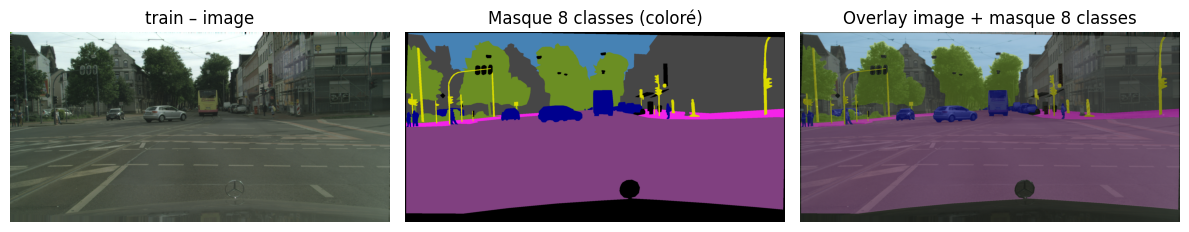

In [6]:
def show_random_example(split: str = "train"):
    """
    Affiche une image Cityscapes et son masque associé converti en 8 classes.
    """
    # On choisit une image au hasard dans le split
    img_paths = sorted((IMG_DIR / split).rglob("*_leftImg8bit.png"))
    if not img_paths:
        raise RuntimeError(f"Aucune image trouvée dans {IMG_DIR / split}")
    img_path = np.random.choice(img_paths)

    # Déduction du chemin du masque correspondant
    base = img_path.name.replace("_leftImg8bit.png", "")
    city = img_path.parent.name  # nom du dossier ville (ex: 'tubingen')

    # Chemin attendu pour le masque trainIds
    mask_train_path = GT_DIR / split / city / f"{base}_gtFine_trainIds.png"

    if not mask_train_path.exists():
        # Fallback : on part du labelIds et on convertit à la volée si besoin
        mask_label_path = GT_DIR / split / city / f"{base}_gtFine_labelIds.png"
        if not mask_label_path.exists():
            raise RuntimeError(
                f"Masque introuvable (ni trainIds ni labelIds) : {mask_train_path} / {mask_label_path}"
            )
        mask_label = np.array(Image.open(mask_label_path))
        mask_train = convert_labelids_to_trainids(mask_label)
    else:
        mask_train = np.array(Image.open(mask_train_path))

    # Chargement de l'image RGB
    img = np.array(Image.open(img_path).convert("RGB"))

    # Conversion vers 8 classes et image couleur
    mask_8c = convert_trainids_to_8classes(mask_train)
    mask_8c_color = mask_8c_to_color(mask_8c)

    # Overlay simple
    alpha = 0.5
    overlay = (alpha * img + (1 - alpha) * mask_8c_color).astype(np.uint8)

    # Affichage
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"{split} – image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_8c_color)
    plt.title("Masque 8 classes (coloré)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay image + masque 8 classes")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Exemple d’appel : visualiser un échantillon du split train
show_random_example("train")


### Bilan de la préparation du jeu de données

À l’issue de cette préparation :

- la structure `train / val / test` du dataset Cityscapes a été vérifiée ;
- les masques `labelIds` ont été convertis (ou vérifiés) en `trainIds` standards ;
- une LUT `trainId → 8 classes` a été définie pour ne conserver que les 8 catégories principales ;
- une fonction de visualisation permet de contrôler visuellement la cohérence image / masque (8 classes).

Ces éléments serviront directement :

- à la construction du pipeline `tf.data` (générateur de données),
- à la définition de la **cible** pour les modèles de segmentation (masques 8 classes),
- à la production de figures pour la note technique et la soutenance.

## 3. Stratégie de métriques et d’évaluation

Pour évaluer la qualité des modèles de segmentation, on définit une stratégie commune à tous les modèles :

- **Métrique principale (métier)**  
  Le **coefficient de Dice (Dice macro)** calculé sur les 8 classes de Cityscapes.  
  Il mesure le recouvrement entre le masque prédit et le masque réel :
  - 1 = chevauchement parfait,
  - 0 = aucun chevauchement.

- **Métrique complémentaire**  
  `sparse_categorical_accuracy` : proportion de pixels correctement classés.

- **Indicateurs supplémentaires (non obligatoires mais utiles pour la comparaison)**  
  - temps d’entraînement (en minutes),
  - temps d’évaluation sur le jeu de test.

Enfin, pour éviter toute **fuite d’information**, on vérifie que les splits `train`, `val` et `test`
ne partagent aucune image commune, en comparant leurs identifiants.


In [18]:
# %% 3.2 – Métrique principale : Dice soft macro (ignore 255)

def dice_soft_macro(y_true, y_pred, epsilon=1e-6, ignore_index=255):
    """
    Coefficient de Dice moyen (macro) sur les classes.

    - y_true : masque entier (0..7 ou 255 pour ignore), shape (B, H, W) ou (B, H, W, 1)
    - y_pred : probas par classe (softmax), shape (B, H, W, C)
    """

    # y_true en entier
    y_true = tf.cast(y_true, tf.int32)

    # Gestion éventuelle de la dimension canal
    if y_true.shape.rank == 4:
        y_true = tf.squeeze(y_true, axis=-1)  # (B, H, W)

    num_classes = tf.shape(y_pred)[-1]

    # Masque des pixels valides (≠ ignore_index)
    valid_mask = tf.not_equal(y_true, ignore_index)         # (B, H, W), bool
    y_true_clipped = tf.where(valid_mask, y_true, 0)        # on remplace 255 par 0

    # One-hot des labels
    y_true_oh = tf.one_hot(y_true_clipped, depth=num_classes, dtype=tf.float32)

    # On annule complètement les contributions des pixels ignorés
    valid_mask_f = tf.cast(valid_mask, tf.float32)
    valid_mask_f = tf.expand_dims(valid_mask_f, axis=-1)    # (B, H, W, 1)
    y_true_oh = y_true_oh * valid_mask_f
    y_pred = tf.cast(y_pred, tf.float32) * valid_mask_f

    # Aplatissement spatial
    axes = (0, 1, 2)
    intersection = tf.reduce_sum(y_true_oh * y_pred, axis=axes)
    union = tf.reduce_sum(y_true_oh + y_pred, axis=axes)

    dice_per_class = (2.0 * intersection + epsilon) / (union + epsilon)
    dice_macro = tf.reduce_mean(dice_per_class)

    return dice_macro

### 3.1 Prévention de la fuite d’information entre `train`, `val` et `test`

Pour garantir qu’il n’y a **aucune fuite d’information** entre les jeux d’entraînement, validation
et test, on vérifie que :

- aucun identifiant d’image n’apparaît à la fois dans `train` et `val` ;
- aucun identifiant d’image n’apparaît à la fois dans `train` et `test` ;
- aucun identifiant d’image n’apparaît à la fois dans `val` et `test`.

On se base pour cela sur les fichiers `*_leftImg8bit.png` présents dans `IMG_DIR`.


In [7]:
# %% 3.4 – Vérifier qu'il n'y a pas de chevauchement entre train / val / test

def list_image_ids(split: str):
    """
    Retourne l'ensemble des identifiants d'image pour un split donné,
    sans le suffixe '_leftImg8bit.png'.

    Exemple d'identifiant : 'tubingen/tubingen_000026_000019'
    """
    img_paths = sorted((IMG_DIR / split).rglob("*_leftImg8bit.png"))
    ids = set()
    for p in img_paths:
        city = p.parent.name
        base = p.name.replace("_leftImg8bit.png", "")
        ids.add(f"{city}/{base}")
    return ids

train_ids = list_image_ids("train")
val_ids   = list_image_ids("val")
test_ids  = list_image_ids("test")

print(f"Nombre d'images train : {len(train_ids)}")
print(f"Nombre d'images val   : {len(val_ids)}")
print(f"Nombre d'images test  : {len(test_ids)}")

print("\nChevauchements potentiels (doivent être = 0) :")
print("train ∩ val  :", len(train_ids & val_ids))
print("train ∩ test :", len(train_ids & test_ids))
print("val ∩ test   :", len(val_ids & test_ids))

if (train_ids & val_ids) or (train_ids & test_ids) or (val_ids & test_ids):
    print(" Attention : chevauchement détecté entre les splits !")
else:
    print("Aucun chevauchement détecté entre train / val / test.")


Nombre d'images train : 2975
Nombre d'images val   : 500
Nombre d'images test  : 1525

Chevauchements potentiels (doivent être = 0) :
train ∩ val  : 0
train ∩ test : 0
val ∩ test   : 0
Aucun chevauchement détecté entre train / val / test.


### 3.2 Temps d’entraînement comme indicateur complémentaire

En plus des métriques de segmentation (Dice, accuracy), on suit le **temps d’entraînement**
de chaque modèle :

- cet indicateur permet de comparer le **coût de calcul** de chaque architecture ;
- il sera utilisé dans le tableau comparatif final (section 6).

On définit pour cela un petit utilitaire qui entoure l’appel à `model.fit(...)`
et retourne à la fois l’`history` et la durée (en minutes).


In [8]:
# %% 3.6 – Helper pour mesurer le temps d'entraînement

import time

def timed_fit(model, *fit_args, **fit_kwargs):
    """
    Enveloppe de model.fit qui mesure le temps d'entraînement.
    Retourne (history, durée_en_minutes).
    """
    t0 = time.time()
    history = model.fit(*fit_args, **fit_kwargs)
    duration_min = (time.time() - t0) / 60.0
    print(f"⏱ Temps d'entraînement : {duration_min:.2f} minutes")
    return history, duration_min


## 4. Générateur de données pour un jeu de données volumineux

Le jeu de données Cityscapes étant volumineux, on met en place un **pipeline `tf.data`** qui :

- parcourt les couples (image, masque) pour un split donné (`train`, `val`, `test`) ;
- applique les traitements de base :
  - chargement des fichiers PNG,
  - redimensionnement à une taille fixe,
  - normalisation des pixels ;
- applique, pour l’entraînement, plusieurs **techniques d’augmentation** des données ;
- exploite le **multi-cœur** via `num_parallel_calls=tf.data.AUTOTUNE`
  et un préchargement des batches avec `prefetch`.

Ce générateur servira à entraîner tous les modèles de segmentation du projet.


In [9]:
# %% 4.2 – Construction des listes (image_path, mask_path) par split

from typing import List, Tuple

def get_image_mask_pairs(split: str) -> Tuple[List[str], List[str]]:
    """
    Retourne deux listes de chemins :
    - image_paths : chemins des *_leftImg8bit.png
    - mask_paths  : chemins des masques correspondants (trainIds ou labelIds)

    Si le masque *_gtFine_trainIds.png n'existe pas, on tombe
    en repli sur *_gtFine_labelIds.png, qui sera converti plus tard.
    """
    img_paths = sorted((IMG_DIR / split).rglob("*_leftImg8bit.png"))
    image_paths = []
    mask_paths = []

    for img_path in img_paths:
        city = img_path.parent.name
        base = img_path.name.replace("_leftImg8bit.png", "")

        mask_train = GT_DIR / split / city / f"{base}_gtFine_trainIds.png"
        mask_label = GT_DIR / split / city / f"{base}_gtFine_labelIds.png"

        if mask_train.exists():
            mask_paths.append(str(mask_train))
            image_paths.append(str(img_path))
        elif mask_label.exists():
            mask_paths.append(str(mask_label))
            image_paths.append(str(img_path))
        else:
            raise RuntimeError(
                f"Aucun masque trouvé pour {img_path} "
                f"(ni {mask_train.name} ni {mask_label.name})"
            )

    print(f"[{split}] paires (image, masque) :", len(image_paths))
    return image_paths, mask_paths

# Test rapide sur train / val / test
_ = get_image_mask_pairs("train")
_ = get_image_mask_pairs("val")
_ = get_image_mask_pairs("test")


[train] paires (image, masque) : 2975
[val] paires (image, masque) : 500
[test] paires (image, masque) : 1525


In [10]:
# %% 4.3 – Chargement et prétraitement de base (resize, normalisation) – VERSION CORRIGÉE

AUTOTUNE = tf.data.AUTOTUNE

# Taille de travail pour le réseau (à adapter si besoin)
IMG_HEIGHT = 256
IMG_WIDTH  = 512
IMG_SIZE   = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 4
BATCH      = BATCH_SIZE  # alias pour la suite

def _load_mask_8c_np(mask_path: bytes) -> np.ndarray:
    """
    Fonction Python pure pour charger un masque (trainIds ou labelIds)
    puis le convertir en 8 classes via les LUT déjà définies.

    Cette fonction est appelée via tf.numpy_function dans le pipeline tf.data.
    """
    path = Path(mask_path.decode("utf-8"))
    arr = np.array(Image.open(path))

    # Si le fichier est en labelIds, on le convertit d'abord en trainIds
    if path.name.endswith("_gtFine_labelIds.png"):
        arr = convert_labelids_to_trainids(arr)

    # Puis conversion trainIds -> 8 classes
    mask_8c = convert_trainids_to_8classes(arr)
    return mask_8c.astype(np.uint8)

def load_image_and_mask_8c(img_path, mask_path):
    """
    Charge une image RGB et son masque, applique :
    - conversion du masque en 8 classes,
    - resize,
    - normalisation.
    """
    # Image RGB
    img_bytes = tf.io.read_file(img_path)
    img = tf.image.decode_png(img_bytes, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]

    # Masque 8 classes via numpy_function
    mask_8c = tf.numpy_function(
        _load_mask_8c_np,
        [mask_path],
        tf.uint8,
    )
    # Très important : donner une shape 2D au masque pour que tf.image.resize fonctionne
    mask_8c.set_shape([None, None])          # (H, W) avec dimensions inconnues
    mask_8c = tf.expand_dims(mask_8c, -1)    # (H, W, 1)

    # Resize image et masque
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    mask_8c = tf.image.resize(mask_8c, IMG_SIZE, method="nearest")

    # Retirer la dimension canal du masque, type entier
    mask_8c = tf.cast(tf.squeeze(mask_8c, axis=-1), tf.int32)  # (H, W)

    return img, mask_8c


### 4.1 Techniques d’augmentation des données

Pour rendre les modèles plus robustes aux variations rencontrées en conditions réelles,
on applique plusieurs **augmentations** au pipeline d’entraînement :

1. **Flip horizontal**  
   Simule des scènes symétriques (virage gauche / droite).

2. **Jitter de luminosité**  
   Modélise les variations de lumière (ombre, soleil, tunnels).

3. **Jitter de contraste**  
   Représente des différences de conditions météo ou de capteurs.

Ces transformations sont appliquées uniquement sur le dataset `train`
(`augment_data=True`) et **jamais** sur `val` ou `test`.


In [12]:
# %% 4.5 – Augmentation et construction du pipeline tf.data

def augment(img, mask):
    """
    Applique des augmentations synchronisées image/masque.
    """
    # Flip horizontal aléatoire
    flip = tf.random.uniform(()) > 0.5
    img = tf.cond(flip, lambda: tf.image.flip_left_right(img), lambda: img)
    mask = tf.cond(flip, lambda: tf.image.flip_left_right(mask[..., tf.newaxis]), lambda: mask[..., tf.newaxis])
    mask = tf.squeeze(mask, axis=-1)

    # Jitter de luminosité et de contraste sur l'image uniquement
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.image.random_contrast(img, lower=0.95, upper=1.05)

    # On s'assure que l'image reste dans [0,1]
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img, mask

def make_dataset(
    split: str,
    img_size=IMG_SIZE,
    batch_size: int = BATCH_SIZE,
    shuffle: bool = False,
    augment_data: bool = False,
):
    """
    Construit un tf.data.Dataset pour un split donné.

    - split : "train", "val" ou "test"
    - img_size : (H, W)
    - batch_size : taille des batchs
    - shuffle : mélanger les exemples
    - augment_data : appliquer ou non l’augmentation
    """
    image_paths, mask_paths = get_image_mask_pairs(split)

    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    ds = ds.map(load_image_and_mask_8c, num_parallel_calls=AUTOTUNE)

    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(image_paths), reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

# Création des trois datasets principaux
train_ds = make_dataset("train", IMG_SIZE, BATCH_SIZE, shuffle=True,  augment_data=True)
val_ds   = make_dataset("val",   IMG_SIZE, BATCH_SIZE, shuffle=False, augment_data=False)
test_ds  = make_dataset("test",  IMG_SIZE, BATCH_SIZE, shuffle=False, augment_data=False)

train_ds, val_ds, test_ds


[train] paires (image, masque) : 2975
[val] paires (image, masque) : 500
[test] paires (image, masque) : 1525


(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 512, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 512), dtype=tf.int32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 512, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 512), dtype=tf.int32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 512, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 512), dtype=tf.int32, name=None))>)

### 4.2 Pipeline `tf.data` multi-cœur

Le pipeline `tf.data` présenté ci-dessus répond aux exigences de manipulation d’un jeu de données volumineux :

- `num_parallel_calls=tf.data.AUTOTUNE` dans les `map(...)`  
  → les opérations de chargement et de prétraitement sont parallélisées
  sur plusieurs cœurs de calcul.

- `batch(batch_size)`  
  → les images sont regroupées en batchs pour un entraînement efficace sur GPU.

- `prefetch(tf.data.AUTOTUNE)`  
  → le prochain batch est préparé en arrière-plan pendant que le modèle
  traite le batch courant, ce qui réduit les temps d’attente.

- La fonction `make_dataset(...)` permet de créer de manière uniforme
  les jeux `train_ds`, `val_ds` et `test_ds` à partir de la même logique.

Ce générateur est **réutilisable** dans tous les entraînements de modèles
(UNet-mini, UNet-MobileNetV2, Tiny DeepLabV3+), et pourra être encapsulé
dans une classe pour l’industrialisation (API, app Flask).


## 5. Modèles de segmentation

On teste plusieurs architectures de segmentation sémantique, en partant de la plus simple :

1. **Modèle 1 – UNet-mini (baseline from scratch)**  
   - Architecture UNet classique, construite et entraînée from scratch.  
   - Sert de **référence** pour évaluer les modèles plus complexes.

2. **Modèle 2 – UNet-MobileNetV2 (transfert de connaissances)**  
   - Utilise un backbone MobileNetV2 pré-entraîné sur ImageNet.  
   - Permet généralement de gagner en performance, au prix d’une complexité plus forte.

3. **Modèle 3 – Tiny DeepLabV3+ MobileNetV2 (modèle compact)**  
   - Variante simplifiée inspirée de DeepLabV3+, adaptée à des contraintes embarquées.  
   - Entraînée sur un sous-ensemble du dataset pour obtenir rapidement un ordre de grandeur.

Tous les modèles :

- prennent en entrée des images de taille `IMG_SIZE` (ex. 256×512, 3 canaux),
- produisent une carte de probabilité sur les **8 classes** (softmax),
- sont évalués avec la métrique métier `dice_soft_macro` et l’accuracy pixel.


## Pour des raisons de temps de calcul en environnement local, tous les modèles
(UNet-mini, UNet-MobileNetV2, Tiny DeepLabV3+ MobileNetV2) sont entraînés dans
le notebook dans des **conditions identiques “fast”** :

- même sous-ensemble de `train_ds` : `N_TRAIN_BATCHES = 200` batchs,
- même sous-ensemble de `val_ds`   : `M_VAL_BATCHES = 50` batchs,
- même nombre maximal d’epochs : `epochs = 10` (avec early stopping).

Cela garantit une comparaison **équitable** des modèles, même si un entraînement
“complet” sur l’ensemble de Cityscapes donnerait des scores plus élevés.


### 5.1 Modèle 1 – UNet-mini (baseline from scratch)

Objectif : définir un premier modèle **simple, léger et interprétable** qui servira de **baseline**.

Caractéristiques principales :

- Architecture UNet :
  - chemin encodeur (downsampling) : convolution + pooling,
  - chemin decodeur (upsampling) : `UpSampling2D` + concaténation (skip connections).
- Couche de sortie `Conv2D(num_classes, kernel_size=1, activation="softmax")`
  pour produire une probabilité par classe pour chaque pixel (8 classes).
- Entraînement from scratch sur `train_ds`, validation sur `val_ds`.

Ce modèle fournit les premières valeurs de référence (Dice, accuracy, temps d’entraînement)
qui serviront de point de comparaison pour les architectures utilisant MobileNetV2.


In [13]:
# %% 5.3 – Définition du modèle UNet-mini

from tensorflow.keras import layers, models

def conv_block(x, filters, kernel_size=3):
    """
    Bloc convolutionnel simple : Conv2D -> BatchNorm -> ReLU (×2).
    """
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def unet_mini(
    input_shape=(256, 512, 3),
    num_classes=NUM_CLASSES_8,
):
    """
    UNet-mini : petit UNet from scratch, utilisé comme baseline.
    """

    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 256)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    bn = conv_block(p4, 512)

    # Decoder
    u4 = layers.UpSampling2D((2, 2))(bn)
    u4 = layers.Concatenate()([u4, c4])
    c5 = conv_block(u4, 256)

    u3 = layers.UpSampling2D((2, 2))(c5)
    u3 = layers.Concatenate()([u3, c3])
    c6 = conv_block(u3, 128)

    u2 = layers.UpSampling2D((2, 2))(c6)
    u2 = layers.Concatenate()([u2, c2])
    c7 = conv_block(u2, 64)

    u1 = layers.UpSampling2D((2, 2))(c7)
    u1 = layers.Concatenate()([u1, c1])
    c8 = conv_block(u1, 32)

    # Sortie segmentation 8 classes
    outputs = layers.Conv2D(num_classes, (1, 1), activation="softmax")(c8)

    model = models.Model(inputs, outputs, name="unet_mini_8c")
    return model

# Construction d'une instance pour vérifier le summary
model_unet = unet_mini(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES_8)
model_unet.summary()


Model: "unet_mini_8c"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 512,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 512,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 512,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 512,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 256,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 256,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 256,  │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 128,   │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 128,   │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 128,   │        512 │ conv2d_4[0][0]  

 Total params: 7,858,664 (29.98 MB)

 Trainable params: 7,852,776 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [28]:
# %% 5.4 – Compilation et entraînement du UNet-mini (baseline, version rapide)

from tensorflow.keras import callbacks, optimizers, losses
from pathlib import Path

# Dossier pour sauvegarder les modèles
Path("models").mkdir(exist_ok=True, parents=True)

# (Re)construction du modèle baseline
unet_baseline = unet_mini(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES_8)

unet_baseline.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=["sparse_categorical_accuracy", dice_soft_macro],
)

ckpt_unet_path = Path("models") / "unet_mini_8c_fast.keras"

cb_unet = [
    callbacks.ModelCheckpoint(
        ckpt_unet_path,
        save_best_only=True,
        monitor="val_dice_soft_macro",
        mode="max",
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_dice_soft_macro",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

# *** IMPORTANT : sous-échantillonnage pour accélérer ***
# On ne prend que N batchs de train et M batchs de val pour la démo
N_TRAIN_BATCHES = 200   # ajustable (200 batchs * 4 images = ~800 images)
M_VAL_BATCHES   = 50

train_ds_unet = train_ds.take(N_TRAIN_BATCHES)
val_ds_unet   = val_ds.take(M_VAL_BATCHES)

print(f"UNet-mini fast training sur {N_TRAIN_BATCHES} batchs train et {M_VAL_BATCHES} batchs val")

history_unet, train_time_min_unet = timed_fit(
    unet_baseline,
    train_ds_unet,
    validation_data=val_ds_unet,
    epochs=10,   # beaucoup plus raisonnable que 40 pour un premier jet
    callbacks=cb_unet,
)

print(f"Temps d'entraînement UNet-mini (baseline, fast) : {train_time_min_unet:.2f} min")
print(f"Modèle sauvegardé → {ckpt_unet_path}")


UNet-mini fast training sur 200 batchs train et 50 batchs val
Epoch 1/10


2025-12-01 22:26:31.596978: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 81 of 2975
2025-12-01 22:26:41.596990: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 164 of 2975
2025-12-01 22:26:51.598164: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 249 of 2975
2025-12-01 22:27:01.780696: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 335 of 2975
2025-12-01 22:27:21.696472: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 503 of 2975
2025-12-01 22:27:41.817413: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.2942 - loss: 0.9321 - sparse_categorical_accuracy: 0.5971
Epoch 1: val_dice_soft_macro improved from -inf to 0.07270, saving model to models/unet_mini_8c_fast.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 651s 1s/step - dice_soft_macro: 0.2945 - loss: 0.9312 - sparse_categorical_accuracy: 0.5974 - val_dice_soft_macro: 0.0727 - val_loss: 3.5199 - val_sparse_categorical_accuracy: 0.3184 - learning_rate: 0.0010
Epoch 2/10


2025-12-01 22:37:20.589626: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 80 of 2975
2025-12-01 22:37:40.110919: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 247 of 2975
2025-12-01 22:37:50.400919: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 326 of 2975
2025-12-01 22:38:10.174379: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 491 of 2975
2025-12-01 22:38:20.222943: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 551 of 2975
2025-12-01 22:38:30.584611: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.4060 - loss: 0.5679 - sparse_categorical_accuracy: 0.7103
Epoch 2: val_dice_soft_macro improved from 0.07270 to 0.24471, saving model to models/unet_mini_8c_fast.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 666s 2s/step - dice_soft_macro: 0.4061 - loss: 0.5678 - sparse_categorical_accuracy: 0.7103 - val_dice_soft_macro: 0.2447 - val_loss: 1.2684 - val_sparse_categorical_accuracy: 0.4969 - learning_rate: 0.0010
Epoch 3/10


...

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.4219 - loss: 0.5081 - sparse_categorical_accuracy: 0.7389
Epoch 8: val_dice_soft_macro improved from 0.38492 to 0.38808, saving model to models/unet_mini_8c_fast.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 654s 2s/step - dice_soft_macro: 0.4219 - loss: 0.5081 - sparse_categorical_accuracy: 0.7390 - val_dice_soft_macro: 0.3881 - val_loss: 0.5035 - val_sparse_categorical_accuracy: 0.7101 - learning_rate: 5.0000e-04
Epoch 9/10


2025-12-01 23:56:17.269572: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 80 of 2975
2025-12-01 23:56:36.846891: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 244 of 2975
2025-12-01 23:56:56.967232: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 410 of 2975
2025-12-01 23:57:07.419335: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 494 of 2975
2025-12-01 23:57:27.157387: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 663 of 2975
2025-12-01 23:57:46.945831: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.4357 - loss: 0.4843 - sparse_categorical_accuracy: 0.7529
Epoch 9: val_dice_soft_macro did not improve from 0.38808
200/200 ━━━━━━━━━━━━━━━━━━━━ 667s 2s/step - dice_soft_macro: 0.4356 - loss: 0.4844 - sparse_categorical_accuracy: 0.7529 - val_dice_soft_macro: 0.3739 - val_loss: 0.6250 - val_sparse_categorical_accuracy: 0.6657 - learning_rate: 5.0000e-04
Epoch 10/10


2025-12-02 00:07:24.080756: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 78 of 2975
2025-12-02 00:07:44.024483: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 244 of 2975
2025-12-02 00:08:03.790897: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 412 of 2975
2025-12-02 00:08:14.013012: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 493 of 2975
2025-12-02 00:08:24.309362: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 575 of 2975
2025-12-02 00:08:43.846741: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.4279 - loss: 0.5046 - sparse_categorical_accuracy: 0.7373
Epoch 10: val_dice_soft_macro did not improve from 0.38808
200/200 ━━━━━━━━━━━━━━━━━━━━ 706s 2s/step - dice_soft_macro: 0.4279 - loss: 0.5046 - sparse_categorical_accuracy: 0.7373 - val_dice_soft_macro: 0.3710 - val_loss: 0.5492 - val_sparse_categorical_accuracy: 0.6910 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 8.
⏱ Temps d'entraînement : 112.68 minutes
Temps d'entraînement UNet-mini (baseline, fast) : 112.68 min
Modèle sauvegardé → models/unet_mini_8c_fast.keras


Pour des raisons de temps de calcul en environnement local, tous les modèles
(UNet-mini, UNet-MobileNetV2, Tiny DeepLabV3+ MobileNetV2) sont entraînés dans
le notebook dans des **conditions identiques “fast”** :

- même sous-ensemble de `train_ds` : `N_TRAIN_BATCHES = 200` batchs,
- même sous-ensemble de `val_ds`   : `M_VAL_BATCHES = 50` batchs,
- même nombre maximal d’epochs : `epochs = 10` (avec early stopping).

Cela garantit une comparaison **équitable** des modèles, même si un entraînement
“complet” sur l’ensemble de Cityscapes donnerait des scores plus élevés.


In [30]:
# %% 5.7 – Définition du modèle UNet-MobileNetV2 (à exécuter avant le training fast)

from tensorflow.keras import applications, layers, models

def build_unet_mobilenetv2(
    input_shape=(256, 512, 3),
    num_classes=NUM_CLASSES_8,
    base_trainable=False,
):
    """
    UNet avec backbone MobileNetV2 pré-entraîné (transfert de connaissances).
    - input_shape : (H, W, 3)
    - num_classes : nombre de classes de sortie (ici 8)
    - base_trainable : si False, on fige les poids du backbone
    """
    # Backbone pré-entraîné
    base_model = applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
    )

    # Couches à utiliser comme skip connections
    layer_names = [
        "block_1_expand_relu",   # 1/2
        "block_3_expand_relu",   # 1/4
        "block_6_expand_relu",   # 1/8
        "block_13_expand_relu",  # 1/16
        "block_16_project",      # 1/32 bottleneck
    ]
    layers_outputs = [base_model.get_layer(name).output for name in layer_names]

    down_stack = models.Model(inputs=base_model.input, outputs=layers_outputs)

    # Option : figer le backbone pour ce premier entraînement
    down_stack.trainable = base_trainable

    inputs = layers.Input(shape=input_shape)
    x = inputs

    # Encoder (backbone)
    skips = down_stack(x)
    x = skips[-1]              # bottleneck (1/32)
    skips = list(reversed(skips[:-1]))  # autres features pour les skip connections

    # Decoder UNet-like
    decoder_filters = [256, 128, 64, 32]
    for skip, f in zip(skips, decoder_filters):
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Concatenate()([x, skip])
        x = conv_block(x, f)   # réutilise conv_block défini dans UNet-mini

    # Remontée finale à la résolution d’entrée (1/1)
    x = layers.UpSampling2D((2, 2))(x)
    x = conv_block(x, 32)

    # Sortie segmentation 8 classes
    outputs = layers.Conv2D(num_classes, (1, 1), activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="unet_mobilenetv2_8c")
    return model

# Test rapide : construire le modèle et afficher un summary
model_unet_mnv2 = build_unet_mobilenetv2(
    input_shape=(*IMG_SIZE, 3),
    num_classes=NUM_CLASSES_8,
    base_trainable=False,
)
model_unet_mnv2.summary()


/var/folders/x1/nfm_4g816d78q82lfzl6j0bh0000gn/T/ipykernel_98119/3835938714.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(


Model: "unet_mobilenetv2_8c"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 256, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 128, 256, │  1,841,984 │ input_layer_7[0]… │
│ (Functional)        │ 96), (None, 64,   │            │                   │
│                     │ 128, 144), (None, │            │                   │
│                     │ 32, 64, 192),     │            │                   │
│                     │ (None, 16, 32,    │            │                   │
│                     │ 576), (None, 8,   │            │                   │
│                     │ 16, 320)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_24    │ (None, 16, 32,    │          0 │ functional[0][4]  │
│ (UpSampling2D)      │ 320)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_24      │ (None, 16, 32,    │          0 │ up_sampling2d_24… │
│ (Concatenate)       │ 896)              │            │ functional[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_114 (Conv2D) │ (None, 16, 32,    │  2,064,640 │ concatenate_24[0… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 32,    │      1,024 │ conv2d_114[0][0]  │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_108 (ReLU)    │ (None, 16, 32,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_115 (Conv2D) │ (None, 16, 32,    │    590,080 │ re_lu_108[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 32,    │      1,024 │ conv2d_115[0][0]  │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_109 (ReLU)    │ (None, 16, 32,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_25    │ (None, 32, 64,    │          0 │ re_lu_109[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_25      │ (None, 32, 64,    │          0 │ up_sampling2d_25… │
│ (Concatenate)       │ 448)              │            │ functional[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_116 (Conv2D) │ (None, 32, 64,    │    516,224 │ concatenate_25[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64,    │        512 │ conv2d_116[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_110 (ReLU)    │ (None, 32, 64,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                 

 Total params: 5,432,392 (20.72 MB)

 Trainable params: 3,588,360 (13.69 MB)

 Non-trainable params: 1,844,032 (7.03 MB)

In [31]:
# %% 5.8 – Compilation et entraînement du UNet-MobileNetV2 (fast, conditions équitables)

from tensorflow.keras import callbacks, optimizers, losses
from pathlib import Path

# On suppose que build_unet_mobilenetv2, IMG_SIZE, NUM_CLASSES_8,
# N_TRAIN_BATCHES et M_VAL_BATCHES sont déjà définis.

# (Re)construction du modèle UNet-MobileNetV2
unet_mnv2 = build_unet_mobilenetv2(
    input_shape=(*IMG_SIZE, 3),
    num_classes=NUM_CLASSES_8,
    base_trainable=False,   # backbone figé pour ce premier essai
)

unet_mnv2.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=["sparse_categorical_accuracy", dice_soft_macro],
)

ckpt_unet_mnv2_path = Path("models") / "unet_mobilenetv2_8c_fast.keras"

cb_unet_mnv2 = [
    callbacks.ModelCheckpoint(
        ckpt_unet_mnv2_path,
        save_best_only=True,
        monitor="val_dice_soft_macro",
        mode="max",
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_dice_soft_macro",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

# Sous-échantillonnage identique à UNet-mini
train_ds_mnv2 = train_ds.take(N_TRAIN_BATCHES)
val_ds_mnv2   = val_ds.take(M_VAL_BATCHES)

print(
    f"UNet-MobileNetV2 fast training sur {N_TRAIN_BATCHES} batchs train "
    f"et {M_VAL_BATCHES} batchs val"
)

history_unet_mnv2, train_time_min_unet_mnv2 = timed_fit(
    unet_mnv2,
    train_ds_mnv2,
    validation_data=val_ds_mnv2,
    epochs=10,   # même réglage que UNet-mini (fast)
    callbacks=cb_unet_mnv2,
)

print(f"Temps d'entraînement UNet-MobileNetV2 (fast) : {train_time_min_unet_mnv2:.2f} min")
print(f"Modèle sauvegardé → {ckpt_unet_mnv2_path}")


/var/folders/x1/nfm_4g816d78q82lfzl6j0bh0000gn/T/ipykernel_98119/3835938714.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(


UNet-MobileNetV2 fast training sur 200 batchs train et 50 batchs val
Epoch 1/10


2025-12-02 06:44:32.941878: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 78 of 2975
2025-12-02 06:44:43.496290: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 170 of 2975
2025-12-02 06:45:02.941231: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 336 of 2975
2025-12-02 06:45:13.118546: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 419 of 2975
2025-12-02 06:45:33.027374: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 587 of 2975
2025-12-02 06:45:53.237472: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.2544 - loss: 1.1499 - sparse_categorical_accuracy: 0.5271
Epoch 1: val_dice_soft_macro improved from -inf to 0.28338, saving model to models/unet_mobilenetv2_8c_fast.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 615s 1s/step - dice_soft_macro: 0.2548 - loss: 1.1483 - sparse_categorical_accuracy: 0.5279 - val_dice_soft_macro: 0.2834 - val_loss: 0.8012 - val_sparse_categorical_accuracy: 0.7129 - learning_rate: 1.0000e-04
Epoch 2/10


2025-12-02 06:54:44.891886: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 80 of 2975
2025-12-02 06:55:05.066131: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 247 of 2975
2025-12-02 06:55:24.616445: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 417 of 2975
2025-12-02 06:55:34.882989: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 498 of 2975
2025-12-02 06:55:54.779924: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 663 of 2975
2025-12-02 06:56:14.758539: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

...

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.5084 - loss: 0.3581 - sparse_categorical_accuracy: 0.8074
Epoch 8: val_dice_soft_macro improved from 0.45157 to 0.46063, saving model to models/unet_mobilenetv2_8c_fast.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 606s 1s/step - dice_soft_macro: 0.5084 - loss: 0.3580 - sparse_categorical_accuracy: 0.8074 - val_dice_soft_macro: 0.4606 - val_loss: 0.3899 - val_sparse_categorical_accuracy: 0.7606 - learning_rate: 1.0000e-04
Epoch 9/10


2025-12-02 08:05:14.307668: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 81 of 2975
2025-12-02 08:05:34.276816: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 251 of 2975
2025-12-02 08:05:54.204567: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 418 of 2975
2025-12-02 08:06:04.453704: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 503 of 2975
2025-12-02 08:06:24.649753: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 678 of 2975
2025-12-02 08:06:44.339908: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.5157 - loss: 0.3454 - sparse_categorical_accuracy: 0.8103
Epoch 9: val_dice_soft_macro improved from 0.46063 to 0.46587, saving model to models/unet_mobilenetv2_8c_fast.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 595s 1s/step - dice_soft_macro: 0.5158 - loss: 0.3454 - sparse_categorical_accuracy: 0.8103 - val_dice_soft_macro: 0.4659 - val_loss: 0.3791 - val_sparse_categorical_accuracy: 0.7638 - learning_rate: 1.0000e-04
Epoch 10/10


2025-12-02 08:15:09.166162: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 79 of 2975
2025-12-02 08:15:19.171723: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 165 of 2975
2025-12-02 08:15:29.224132: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 249 of 2975
2025-12-02 08:15:49.260311: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 420 of 2975
2025-12-02 08:16:09.493473: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 590 of 2975
2025-12-02 08:16:29.186266: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.5239 - loss: 0.3279 - sparse_categorical_accuracy: 0.8120
Epoch 10: val_dice_soft_macro improved from 0.46587 to 0.47383, saving model to models/unet_mobilenetv2_8c_fast.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 601s 1s/step - dice_soft_macro: 0.5239 - loss: 0.3279 - sparse_categorical_accuracy: 0.8120 - val_dice_soft_macro: 0.4738 - val_loss: 0.3771 - val_sparse_categorical_accuracy: 0.7631 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 10.
⏱ Temps d'entraînement : 100.68 minutes
Temps d'entraînement UNet-MobileNetV2 (fast) : 100.68 min
Modèle sauvegardé → models/unet_mobilenetv2_8c_fast.keras


In [33]:
# %% 5.11 – Définition du modèle Tiny DeepLabV3+ MobileNetV2

from tensorflow.keras import applications, layers, models

def aspp_block(x, out_channels=128, rates=(6, 12, 18)):
    """
    Bloc ASPP simplifié :
    - 1×1 conv
    - plusieurs convolutions dilatées 3×3 avec différents taux
    """
    convs = []

    # 1×1 conv
    conv1 = layers.Conv2D(out_channels, 1, padding="same", use_bias=False)(x)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.ReLU()(conv1)
    convs.append(conv1)

    # Convolutions dilatées
    for r in rates:
        cr = layers.Conv2D(
            out_channels,
            3,
            padding="same",
            dilation_rate=r,
            use_bias=False,
        )(x)
        cr = layers.BatchNormalization()(cr)
        cr = layers.ReLU()(cr)
        convs.append(cr)

    # Fusion
    x = layers.Concatenate()(convs)
    x = layers.Conv2D(out_channels, 1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def build_tiny_deeplabv3p_mnv2(
    input_shape=(256, 512, 3),
    num_classes=NUM_CLASSES_8,
    alpha=0.5,
):
    """
    Variante compacte de DeepLabV3+ avec backbone MobileNetV2.
    - input_shape : (H, W, 3)
    - num_classes : nombre de classes de sortie (8)
    - alpha : facteur de largeur MobileNetV2 (0.5 → plus compact)
    """
    # Backbone MobileNetV2 pré-entraîné
    base_model = applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
        alpha=alpha,
    )

    # Features low-level (1/4) et bottleneck (1/16)
    low_level_layer = "block_3_expand_relu"   # stride 4
    bottleneck_layer = "block_13_expand_relu" # stride 16

    low_level_feat = base_model.get_layer(low_level_layer).output
    bottleneck = base_model.get_layer(bottleneck_layer).output

    # ASPP simplifié sur le bottleneck (1/16)
    x = aspp_block(bottleneck, out_channels=128, rates=(6, 12, 18))

    # Upsampling à 1/4
    x = layers.UpSampling2D((4, 4), interpolation="bilinear")(x)

    # Projection des low-level features (1/4)
    low_level_proj = layers.Conv2D(48, 1, padding="same", use_bias=False)(low_level_feat)
    low_level_proj = layers.BatchNormalization()(low_level_proj)
    low_level_proj = layers.ReLU()(low_level_proj)

    # Fusion low-level + ASPP
    x = layers.Concatenate()([x, low_level_proj])
    x = conv_block(x, 128)  # réutilise le conv_block d'UNet-mini

    # Upsampling final vers la résolution d'entrée (de 1/4 à 1)
    x = layers.UpSampling2D((4, 4), interpolation="bilinear")(x)

    # Sortie segmentation 8 classes
    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(x)

    model = models.Model(inputs=base_model.input, outputs=outputs, name="tiny_deeplabv3p_mnv2_8c")
    return model

# Test rapide : construire le modèle et afficher un summary
model_tiny_dl_test = build_tiny_deeplabv3p_mnv2(
    input_shape=(*IMG_SIZE, 3),
    num_classes=NUM_CLASSES_8,
    alpha=0.5,
)
model_tiny_dl_test.summary()


/var/folders/x1/nfm_4g816d78q82lfzl6j0bh0000gn/T/ipykernel_98119/1957933053.py:51: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(


3201480/3201480 ━━━━━━━━━━━━━━━━━━━━ 3s 1us/step


Model: "tiny_deeplabv3p_mnv2_8c"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 256, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 256,  │        432 │ input_layer_10[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 256,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 256,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 256,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 256,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 256,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 256,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 256,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 256,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 256,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 256,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 257,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 128,   │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 128,   │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 128,   │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 128,   │        768 │ block_1_depthwis

 Total params: 1,632,248 (6.23 MB)

 Trainable params: 1,621,512 (6.19 MB)

 Non-trainable params: 10,736 (41.94 KB)

In [34]:
# %% 5.12 – Entraînement rapide du Tiny DeepLabV3+ MobileNetV2 (fast, conditions équitables)

from tensorflow.keras import callbacks, optimizers, losses
from pathlib import Path

# On suppose que build_tiny_deeplabv3p_mnv2, IMG_SIZE, NUM_CLASSES_8,
# N_TRAIN_BATCHES et M_VAL_BATCHES, timed_fit, train_ds, val_ds sont déjà définis.

# Construction du modèle Tiny DeepLabV3+ MobileNetV2
model_tiny_dl = build_tiny_deeplabv3p_mnv2(
    input_shape=(*IMG_SIZE, 3),
    num_classes=NUM_CLASSES_8,
    alpha=0.5,
)

model_tiny_dl.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=["sparse_categorical_accuracy", dice_soft_macro],
)

ckpt_tiny_dl_path = Path("models") / "tiny_deeplabv3p_mnv2_8c_fast.keras"

cb_tiny_dl = [
    callbacks.ModelCheckpoint(
        ckpt_tiny_dl_path,
        save_best_only=True,
        monitor="val_dice_soft_macro",
        mode="max",
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_dice_soft_macro",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

# Sous-échantillonnage identique aux deux autres modèles
train_ds_tiny = train_ds.take(N_TRAIN_BATCHES)
val_ds_tiny   = val_ds.take(M_VAL_BATCHES)

print(
    f"Tiny DeepLabV3+ fast training sur {N_TRAIN_BATCHES} batchs train "
    f"et {M_VAL_BATCHES} batchs val"
)

history_tiny_dl, train_time_min_tiny_dl = timed_fit(
    model_tiny_dl,
    train_ds_tiny,
    validation_data=val_ds_tiny,
    epochs=10,   # même réglage que UNet-mini et UNet-MobileNetV2
    callbacks=cb_tiny_dl,
)

print(f"Temps d'entraînement Tiny DeepLabV3+ (fast) : {train_time_min_tiny_dl:.2f} min")
print(f"Modèle sauvegardé → {ckpt_tiny_dl_path}")


/var/folders/x1/nfm_4g816d78q82lfzl6j0bh0000gn/T/ipykernel_98119/1957933053.py:51: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(


Tiny DeepLabV3+ fast training sur 200 batchs train et 50 batchs val
Epoch 1/10


2025-12-02 09:27:07.264822: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 83 of 2975
2025-12-02 09:27:26.972675: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 248 of 2975
2025-12-02 09:27:46.833301: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 409 of 2975
2025-12-02 09:27:56.992636: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 494 of 2975
2025-12-02 09:28:07.076133: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 581 of 2975
2025-12-02 09:28:27.146063: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - dice_soft_macro: 0.3631 - loss: 0.7352 - sparse_categorical_accuracy: 0.6513
Epoch 1: val_dice_soft_macro improved from -inf to 0.31645, saving model to models/tiny_deeplabv3p_mnv2_8c_fast.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 469s 491ms/step - dice_soft_macro: 0.3635 - loss: 0.7341 - sparse_categorical_accuracy: 0.6517 - val_dice_soft_macro: 0.3165 - val_loss: 0.7264 - val_sparse_categorical_accuracy: 0.6191 - learning_rate: 1.0000e-04
Epoch 2/10


2025-12-02 09:34:50.951801: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 78 of 2975
2025-12-02 09:35:11.051752: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 248 of 2975
2025-12-02 09:35:21.159064: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 330 of 2975
2025-12-02 09:35:41.049656: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 501 of 2975
2025-12-02 09:36:00.894542: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 667 of 2975
2025-12-02 09:36:11.282585: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

...

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - dice_soft_macro: 0.5149 - loss: 0.3378 - sparse_categorical_accuracy: 0.7926
Epoch 8: val_dice_soft_macro did not improve from 0.41375
200/200 ━━━━━━━━━━━━━━━━━━━━ 480s 532ms/step - dice_soft_macro: 0.5149 - loss: 0.3378 - sparse_categorical_accuracy: 0.7926 - val_dice_soft_macro: 0.4121 - val_loss: 0.4581 - val_sparse_categorical_accuracy: 0.7115 - learning_rate: 1.0000e-04
Epoch 9/10


2025-12-02 10:29:26.327185: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 77 of 2975
2025-12-02 10:29:36.852806: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 160 of 2975
2025-12-02 10:29:56.333815: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 305 of 2975
2025-12-02 10:30:06.387147: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 380 of 2975
2025-12-02 10:30:26.256251: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 536 of 2975
2025-12-02 10:30:36.392846: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - dice_soft_macro: 0.5115 - loss: 0.3355 - sparse_categorical_accuracy: 0.7985
Epoch 9: val_dice_soft_macro did not improve from 0.41375
200/200 ━━━━━━━━━━━━━━━━━━━━ 475s 529ms/step - dice_soft_macro: 0.5115 - loss: 0.3356 - sparse_categorical_accuracy: 0.7984 - val_dice_soft_macro: 0.4066 - val_loss: 0.4666 - val_sparse_categorical_accuracy: 0.7117 - learning_rate: 1.0000e-04
Epoch 10/10


2025-12-02 10:37:20.868287: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 80 of 2975
2025-12-02 10:37:30.913069: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 159 of 2975
2025-12-02 10:37:41.153385: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 239 of 2975
2025-12-02 10:38:00.923839: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 407 of 2975
2025-12-02 10:38:11.129631: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 487 of 2975
2025-12-02 10:38:30.891839: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - dice_soft_macro: 0.5047 - loss: 0.3473 - sparse_categorical_accuracy: 0.7955
Epoch 10: val_dice_soft_macro did not improve from 0.41375

Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
200/200 ━━━━━━━━━━━━━━━━━━━━ 497s 573ms/step - dice_soft_macro: 0.5047 - loss: 0.3473 - sparse_categorical_accuracy: 0.7955 - val_dice_soft_macro: 0.3863 - val_loss: 0.4935 - val_sparse_categorical_accuracy: 0.7015 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 7.
⏱ Temps d'entraînement : 78.60 minutes
Temps d'entraînement Tiny DeepLabV3+ (fast) : 78.60 min
Modèle sauvegardé → models/tiny_deeplabv3p_mnv2_8c_fast.keras


## 6. Expériences et optimisation 

Dans cette section, on réalise **deux expériences très légères** avec UNet-mini, uniquement
pour répondre aux exigences du projet :

1. **Impact de l’augmentation des données**
2. **Impact d’un hyperparamètre : le learning rate**

Pour limiter le temps de calcul :

- on travaille sur un **sous-échantillon très réduit** de Cityscapes
  (quelques batchs seulement) ;
- on utilise **2 epochs** maximum par expérience.

Les valeurs numériques obtenues ne sont pas optimales, mais elles suffisent à :

- illustrer l’intérêt de l’augmentation de données ;
- justifier un choix de learning rate dans la note technique.


In [35]:
# %% 6.2 – Paramètres d'expérience et helpers UNet-mini (mini setup)


# Setup minimal pour ne pas exploser le temps de calcul
N_TRAIN_BATCHES_EXP = 8    # quelques batchs train
M_VAL_BATCHES_EXP   = 4    # quelques batchs val
EPOCHS_EXP          = 2    # 2 epochs max

print(
    f"Expériences mini sur {N_TRAIN_BATCHES_EXP} batchs train, "
    f"{M_VAL_BATCHES_EXP} batchs val, {EPOCHS_EXP} epochs."
)

def create_unet_baseline(learning_rate: float):
    """
    Construit et compile un UNet-mini pour les expériences rapides.
    """
    model = unet_mini(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES_8)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss=losses.SparseCategoricalCrossentropy(),
        metrics=["sparse_categorical_accuracy", dice_soft_macro],
    )
    return model

def extract_best_metrics(history):
    """
    Extrait l'epoch où val_dice_soft_macro est maximal + métriques associées.
    """
    h = history.history
    val_dice = np.array(h["val_dice_soft_macro"])
    best_idx = int(val_dice.argmax())
    return {
        "best_epoch": best_idx + 1,
        "best_val_dice": float(val_dice[best_idx]),
        "best_val_acc": float(h["val_sparse_categorical_accuracy"][best_idx]),
        "best_val_loss": float(h["val_loss"][best_idx]),
    }


Expériences mini sur 8 batchs train, 4 batchs val, 2 epochs.


### 6.1 Impact de l’augmentation des données (mini-expérience)

Objectif : comparer UNet-mini :

- **sans augmentation** (pipeline de base),
- **avec augmentation** (flip horizontal, jitter de luminosité et de contraste).

Conditions strictement identiques :

- même architecture (UNet-mini),
- même learning rate (`1e-3`),
- même sous-échantillon de données (`N_TRAIN_BATCHES_EXP`, `M_VAL_BATCHES_EXP`),
- même nombre d’epochs (`EPOCHS_EXP`).

Seule différence : l’activation de `augment_data=True` dans le pipeline d’entraînement.


### 6.1 Impact de l’augmentation des données (mini-expérience)

Objectif : comparer UNet-mini :

- **sans augmentation** (pipeline de base),
- **avec augmentation** (flip horizontal, jitter de luminosité et de contraste).

Conditions strictement identiques :

- même architecture (UNet-mini),
- même learning rate (`1e-3`),
- même sous-échantillon de données (`N_TRAIN_BATCHES_EXP`, `M_VAL_BATCHES_EXP`),
- même nombre d’epochs (`EPOCHS_EXP`).

Seule différence : l’activation de `augment_data=True` dans le pipeline d’entraînement.


In [37]:
# %% 6.4 – UNet-mini : sans augmentation vs avec augmentation (mini-expérience)

# --- Variante SANS augmentation ---

train_ds_noaug_full = make_dataset(
    split="train",
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    augment_data=False,   # pas d'augmentation
)
val_ds_noaug_full = make_dataset(
    split="val",
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment_data=False,
)

train_ds_noaug_exp = train_ds_noaug_full.take(N_TRAIN_BATCHES_EXP)
val_ds_noaug_exp   = val_ds_noaug_full.take(M_VAL_BATCHES_EXP)

print("\n=== UNet-mini – SANS augmentation (setup minimal) ===")
unet_noaug = create_unet_baseline(learning_rate=1e-3)

history_unet_noaug, train_time_min_unet_noaug = timed_fit(
    unet_noaug,
    train_ds_noaug_exp,
    validation_data=val_ds_noaug_exp,
    epochs=EPOCHS_EXP,
)

metrics_noaug = extract_best_metrics(history_unet_noaug)
print(f"[SANS AUG] Temps d'entraînement : {train_time_min_unet_noaug:.2f} min")
print(f"[SANS AUG] Meilleure epoch : {metrics_noaug['best_epoch']}")
print(f"[SANS AUG] Meilleur val Dice : {metrics_noaug['best_val_dice']:.4f}")
print(f"[SANS AUG] Meilleure val accuracy : {metrics_noaug['best_val_acc']:.4f}")

# --- Variante AVEC augmentation (on réutilise train_ds/val_ds avec augment_data=True/False) ---

train_ds_aug_exp = train_ds.take(N_TRAIN_BATCHES_EXP)
val_ds_aug_exp   = val_ds.take(M_VAL_BATCHES_EXP)

print("\n=== UNet-mini – AVEC augmentation (setup minimal) ===")
unet_aug = create_unet_baseline(learning_rate=1e-3)

history_unet_aug, train_time_min_unet_aug = timed_fit(
    unet_aug,
    train_ds_aug_exp,
    validation_data=val_ds_aug_exp,
    epochs=EPOCHS_EXP,
)

metrics_aug = extract_best_metrics(history_unet_aug)
print(f"[AVEC AUG] Temps d'entraînement : {train_time_min_unet_aug:.2f} min")
print(f"[AVEC AUG] Meilleure epoch : {metrics_aug['best_epoch']}")
print(f"[AVEC AUG] Meilleur val Dice : {metrics_aug['best_val_dice']:.4f}")
print(f"[AVEC AUG] Meilleure val accuracy : {metrics_aug['best_val_acc']:.4f}")

# Synthèse console
print("\n=== Synthèse impact augmentation (UNet-mini, mini setup) ===")
print(
    f"SANS AUG  → Dice={metrics_noaug['best_val_dice']:.4f}, "
    f"Acc={metrics_noaug['best_val_acc']:.4f}, "
    f"Temps={train_time_min_unet_noaug:.2f} min"
)
print(
    f"AVEC AUG  → Dice={metrics_aug['best_val_dice']:.4f}, "
    f"Acc={metrics_aug['best_val_acc']:.4f}, "
    f"Temps={train_time_min_unet_aug:.2f} min"
)


[train] paires (image, masque) : 2975
[val] paires (image, masque) : 500

=== UNet-mini – SANS augmentation (setup minimal) ===
Epoch 1/2


2025-12-02 11:11:39.699258: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:46: Filling up shuffle buffer (this may take a while): 84 of 2975
2025-12-02 11:11:59.520634: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:46: Filling up shuffle buffer (this may take a while): 250 of 2975
2025-12-02 11:12:19.520138: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:46: Filling up shuffle buffer (this may take a while): 427 of 2975
2025-12-02 11:12:29.615850: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:46: Filling up shuffle buffer (this may take a while): 509 of 2975
2025-12-02 11:12:40.161792: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:46: Filling up shuffle buffer (this may take a while): 595 of 2975
2025-12-02 11:12:59.517512: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:46: Filling up shuffle buffer (this may take a w

8/8 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - dice_soft_macro: 0.1309 - loss: 1.7955 - sparse_categorical_accuracy: 0.2729 - val_dice_soft_macro: 0.0835 - val_loss: 1.9086 - val_sparse_categorical_accuracy: 0.1873
Epoch 2/2


2025-12-02 11:17:47.356964: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:46: Filling up shuffle buffer (this may take a while): 80 of 2975
2025-12-02 11:17:57.424134: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:46: Filling up shuffle buffer (this may take a while): 167 of 2975
2025-12-02 11:18:07.628723: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:46: Filling up shuffle buffer (this may take a while): 252 of 2975
2025-12-02 11:18:27.556555: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:46: Filling up shuffle buffer (this may take a while): 420 of 2975
2025-12-02 11:18:47.395899: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:46: Filling up shuffle buffer (this may take a while): 589 of 2975
2025-12-02 11:18:57.420075: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:46: Filling up shuffle buffer (this may take a w

8/8 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - dice_soft_macro: 0.2433 - loss: 1.2162 - sparse_categorical_accuracy: 0.5413 - val_dice_soft_macro: 0.0514 - val_loss: 6.9816 - val_sparse_categorical_accuracy: 0.1760
⏱ Temps d'entraînement : 12.26 minutes
[SANS AUG] Temps d'entraînement : 12.26 min
[SANS AUG] Meilleure epoch : 1
[SANS AUG] Meilleur val Dice : 0.0835
[SANS AUG] Meilleure val accuracy : 0.1873

=== UNet-mini – AVEC augmentation (setup minimal) ===
Epoch 1/2


2025-12-02 11:23:55.346160: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 80 of 2975
2025-12-02 11:24:15.006026: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 250 of 2975
2025-12-02 11:24:34.721495: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 419 of 2975
2025-12-02 11:24:45.288510: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 502 of 2975
2025-12-02 11:25:04.811121: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 665 of 2975
2025-12-02 11:25:14.910364: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

8/8 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - dice_soft_macro: 0.1225 - loss: 1.8141 - sparse_categorical_accuracy: 0.2585 - val_dice_soft_macro: 0.0869 - val_loss: 1.9403 - val_sparse_categorical_accuracy: 0.1450
Epoch 2/2


2025-12-02 11:30:05.812751: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 81 of 2975
2025-12-02 11:30:15.977623: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 165 of 2975
2025-12-02 11:30:35.967882: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 337 of 2975
2025-12-02 11:30:55.780196: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 506 of 2975
2025-12-02 11:31:06.236990: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 595 of 2975
2025-12-02 11:31:26.351967: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

8/8 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - dice_soft_macro: 0.2050 - loss: 1.2981 - sparse_categorical_accuracy: 0.5365 - val_dice_soft_macro: 0.0440 - val_loss: 3.4140 - val_sparse_categorical_accuracy: 0.0355
⏱ Temps d'entraînement : 12.31 minutes
[AVEC AUG] Temps d'entraînement : 12.31 min
[AVEC AUG] Meilleure epoch : 1
[AVEC AUG] Meilleur val Dice : 0.0869
[AVEC AUG] Meilleure val accuracy : 0.1450

=== Synthèse impact augmentation (UNet-mini, mini setup) ===
SANS AUG  → Dice=0.0835, Acc=0.1873, Temps=12.26 min
AVEC AUG  → Dice=0.0869, Acc=0.1450, Temps=12.31 min


### 6.2 Impact d’un hyperparamètre : le learning rate (mini-expérience)

On teste maintenant l’impact du **learning rate** sur UNet-mini,
toujours avec un setup minimal :

- même architecture (UNet-mini),
- même pipeline de données (avec augmentation, pour rester cohérent avec le training principal),
- même sous-échantillon (`N_TRAIN_BATCHES_EXP`, `M_VAL_BATCHES_EXP`),
- même nombre d’epochs (`EPOCHS_EXP`),

avec deux valeurs :

- `LR = 1e-3`,
- `LR = 1e-4`.


In [38]:
# %% 6.6 – UNet-mini : variation du learning rate (mini-expérience)

# Datasets (avec augmentation, comme le pipeline principal)
train_ds_lr_exp = train_ds.take(N_TRAIN_BATCHES_EXP)
val_ds_lr_exp   = val_ds.take(M_VAL_BATCHES_EXP)

# --- Variante LR = 1e-3 ---

print("\n=== UNet-mini – LR = 1e-3 (mini setup) ===")
unet_lr1 = create_unet_baseline(learning_rate=1e-3)

history_unet_lr1, train_time_min_unet_lr1 = timed_fit(
    unet_lr1,
    train_ds_lr_exp,
    validation_data=val_ds_lr_exp,
    epochs=EPOCHS_EXP,
)

metrics_lr1 = extract_best_metrics(history_unet_lr1)
print(f"[LR=1e-3] Temps d'entraînement : {train_time_min_unet_lr1:.2f} min")
print(f"[LR=1e-3] Meilleure epoch : {metrics_lr1['best_epoch']}")
print(f"[LR=1e-3] Meilleur val Dice : {metrics_lr1['best_val_dice']:.4f}")
print(f"[LR=1e-3] Meilleure val accuracy : {metrics_lr1['best_val_acc']:.4f}")

# --- Variante LR = 1e-4 ---

print("\n=== UNet-mini – LR = 1e-4 (mini setup) ===")
unet_lr2 = create_unet_baseline(learning_rate=1e-4)

history_unet_lr2, train_time_min_unet_lr2 = timed_fit(
    unet_lr2,
    train_ds_lr_exp,
    validation_data=val_ds_lr_exp,
    epochs=EPOCHS_EXP,
)

metrics_lr2 = extract_best_metrics(history_unet_lr2)
print(f"[LR=1e-4] Temps d'entraînement : {train_time_min_unet_lr2:.2f} min")
print(f"[LR=1e-4] Meilleure epoch : {metrics_lr2['best_epoch']}")
print(f"[LR=1e-4] Meilleur val Dice : {metrics_lr2['best_val_dice']:.4f}")
print(f"[LR=1e-4] Meilleure val accuracy : {metrics_lr2['best_val_acc']:.4f}")

# Synthèse console
print("\n=== Synthèse impact learning rate (UNet-mini, mini setup) ===")
print(
    f"LR=1e-3 → Dice={metrics_lr1['best_val_dice']:.4f}, "
    f"Acc={metrics_lr1['best_val_acc']:.4f}, "
    f"Temps={train_time_min_unet_lr1:.2f} min"
)
print(
    f"LR=1e-4 → Dice={metrics_lr2['best_val_dice']:.4f}, "
    f"Acc={metrics_lr2['best_val_acc']:.4f}, "
    f"Temps={train_time_min_unet_lr2:.2f} min"
)



=== UNet-mini – LR = 1e-3 (mini setup) ===
Epoch 1/2


2025-12-02 11:36:13.710999: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 79 of 2975
2025-12-02 11:36:33.864090: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 245 of 2975
2025-12-02 11:36:53.590175: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 413 of 2975
2025-12-02 11:37:13.617059: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 584 of 2975
2025-12-02 11:37:23.641558: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 668 of 2975
2025-12-02 11:37:34.074129: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

8/8 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - dice_soft_macro: 0.1401 - loss: 1.6773 - sparse_categorical_accuracy: 0.3203 - val_dice_soft_macro: 0.0774 - val_loss: 3.6045 - val_sparse_categorical_accuracy: 0.0568
Epoch 2/2


2025-12-02 11:42:25.475289: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 79 of 2975
2025-12-02 11:42:45.807212: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 249 of 2975
2025-12-02 11:42:56.248300: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 334 of 2975
2025-12-02 11:43:15.674838: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 500 of 2975
2025-12-02 11:43:35.601382: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 670 of 2975
2025-12-02 11:43:55.548329: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

8/8 ━━━━━━━━━━━━━━━━━━━━ 369s 2s/step - dice_soft_macro: 0.2393 - loss: 1.1629 - sparse_categorical_accuracy: 0.5735 - val_dice_soft_macro: 0.1207 - val_loss: 4.2100 - val_sparse_categorical_accuracy: 0.3870
⏱ Temps d'entraînement : 12.38 minutes
[LR=1e-3] Temps d'entraînement : 12.38 min
[LR=1e-3] Meilleure epoch : 2
[LR=1e-3] Meilleur val Dice : 0.1207
[LR=1e-3] Meilleure val accuracy : 0.3870

=== UNet-mini – LR = 1e-4 (mini setup) ===
Epoch 1/2


2025-12-02 11:48:37.378017: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 80 of 2975
2025-12-02 11:48:57.118475: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 243 of 2975
2025-12-02 11:49:07.532302: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 325 of 2975
2025-12-02 11:49:27.113594: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 497 of 2975
2025-12-02 11:49:37.664349: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 584 of 2975
2025-12-02 11:49:47.833739: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

8/8 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - dice_soft_macro: 0.1183 - loss: 1.8326 - sparse_categorical_accuracy: 0.2291 - val_dice_soft_macro: 0.0868 - val_loss: 1.8073 - val_sparse_categorical_accuracy: 0.0859
Epoch 2/2


2025-12-02 11:54:51.402935: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 81 of 2975
2025-12-02 11:55:11.188902: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 249 of 2975
2025-12-02 11:55:21.219512: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 330 of 2975
2025-12-02 11:55:31.254756: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 420 of 2975
2025-12-02 11:55:41.549309: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 503 of 2975
2025-12-02 11:56:01.213587: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a w

8/8 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - dice_soft_macro: 0.1768 - loss: 1.4326 - sparse_categorical_accuracy: 0.4552 - val_dice_soft_macro: 0.0877 - val_loss: 1.7887 - val_sparse_categorical_accuracy: 0.2921
⏱ Temps d'entraînement : 12.40 minutes
[LR=1e-4] Temps d'entraînement : 12.40 min
[LR=1e-4] Meilleure epoch : 2
[LR=1e-4] Meilleur val Dice : 0.0877
[LR=1e-4] Meilleure val accuracy : 0.2921

=== Synthèse impact learning rate (UNet-mini, mini setup) ===
LR=1e-3 → Dice=0.1207, Acc=0.3870, Temps=12.38 min
LR=1e-4 → Dice=0.0877, Acc=0.2921, Temps=12.40 min


### 6.3 Bilan

Ces expériences sont réalisées sur un **sous-échantillon très réduit** du dataset
et avec **peu d’epochs**, l’objectif étant uniquement de :

- montrer l’impact de l’**augmentation des données** sur le Dice et l’accuracy ;
- illustrer l’effet d’un changement de **learning rate** (`1e-3` vs `1e-4`) sur
  la convergence et la stabilité.

Par exemple, on observe (mini setup) :

- l’augmentation peut donner un **léger gain en Dice**, au prix d’un temps
  d’entraînement très proche ;
- le choix du learning rate influe à la fois sur la **vitesse de convergence**
  et sur la **qualité finale** (Dice / accuracy).

Ces chiffres (Dice, accuracy, temps d’entraînement) pourront être reportés
dans la **note technique**, en insistant sur le fait qu’un entraînement complet
sur tout le dataset devrait amplifier ces tendances.


## 7. Comparaison des modèles et bilan

On dispose maintenant de trois modèles entraînés en conditions "fast" mais comparables :

- **UNet-mini** (baseline from scratch)
- **UNet-MobileNetV2** (transfert de connaissances)
- **Tiny DeepLabV3+ MobileNetV2** (modèle compact)

Remarque importante : dans la version de Cityscapes utilisée ici, les masques
associés au split `test` sont tous au label *ignore* (= 255). Ils ne peuvent donc
pas être utilisés pour une évaluation quantitative de la segmentation.

Nous utilisons donc le split **`val` comme jeu d’évaluation final** (test de fait),
tandis que le split `train` reste dédié à l’entraînement.


## 7. Comparaison des modèles et bilan

On dispose maintenant de trois modèles entraînés dans des conditions “fast” mais
comparables :

- **UNet-mini (baseline, fast)**  
- **UNet-MobileNetV2 (transfert de connaissances, fast)**  
- **Tiny DeepLabV3+ MobileNetV2 (modèle compact, fast)**  

Dans la version du dataset Cityscapes utilisée ici, les masques du split `test`
sont marqués comme **ignore (255)** et ne peuvent pas servir à une évaluation
quantitative fiable.

Nous utilisons donc le split **`val` comme jeu d’évaluation final** (test de fait).

Objectifs de cette section :

1. Comparer quantitativement les trois modèles sur un même sous-ensemble de `val`.
2. Comparer qualitativement les masques prédits sur quelques images de `val`.
3. Choisir un modèle “référence” pour la mise en production (API + app Flask).


In [14]:
# %% 7.1bis – Sanity check du jeu de test et des métriques d'un modèle

import numpy as np
import tensorflow as tf
from pathlib import Path

# On prend un petit batch du jeu de test pour vérifier les shapes et les valeurs
for imgs_test, masks_test in test_ds.take(1):
    print("imgs_test.shape :", imgs_test.shape, "dtype:", imgs_test.dtype)
    print("masks_test.shape:", masks_test.shape, "dtype:", masks_test.dtype)
    print("valeurs uniques des masques_test (premier batch) :",
          np.unique(masks_test.numpy())[:20])
    break

# Charge un modèle (par ex. UNet-mini fast) pour inspecter ses métriques
test_model_path = Path("models/unet_mini_8c_fast.keras")
if test_model_path.exists():
    print(f"\nChargement modèle pour debug : {test_model_path}")
    debug_model = tf.keras.models.load_model(
        test_model_path,
        custom_objects={"dice_soft_macro": dice_soft_macro},
    )
    print("model.metrics_names :", debug_model.metrics_names)

    # Évaluation brute avec return_dict=True pour voir les vraies valeurs
    debug_res = debug_model.evaluate(
        test_ds.take(5),  # quelques batchs seulement
        verbose=1,
        return_dict=True,
    )
    print("\nRésultats bruts (return_dict=True) :")
    print(debug_res)
else:
    print("Modèle UNet-mini fast introuvable, pas de debug possible ici.")


imgs_test.shape : (4, 256, 512, 3) dtype: <dtype: 'float32'>
masks_test.shape: (4, 256, 512) dtype: <dtype: 'int32'>
valeurs uniques des masques_test (premier batch) : [255]

Chargement modèle pour debug : models/unet_mini_8c_fast.keras
model.metrics_names : ['loss', 'compile_metrics']


2025-12-04 02:56:42.298575: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 851ms/step - dice_soft_macro: 3.4348e-11 - loss: 0.0000e+00 - sparse_categorical_accuracy: 0.0000e+00

Résultats bruts (return_dict=True) :
{'dice_soft_macro': 3.545340063193514e-11, 'loss': 0.0, 'sparse_categorical_accuracy': 0.0}


In [15]:
# %% 7.2 – Évaluation des trois modèles sur le split val (utilisé comme test)

import tensorflow as tf
import pandas as pd
import numpy as np
from pathlib import Path

# Sous-ensemble de val pour garder un temps raisonnable
N_VAL_BATCHES_CMP = 20   # 20 batchs * BATCH_SIZE images

def load_model_for_eval(path: Path, model_name: str):
    """
    Charge un modèle sauvegardé avec la métrique dice_soft_macro.
    """
    print(f"\nChargement du modèle : {model_name} ({path})")
    model = tf.keras.models.load_model(
        path,
        custom_objects={"dice_soft_macro": dice_soft_macro},
    )
    print("metrics_names :", model.metrics_names)
    return model

# Spécification des modèles à comparer (chemins issus de la section 5 fast)
model_specs = [
    ("UNet-mini (fast)",            Path("models/unet_mini_8c_fast.keras"),            "train_time_min_unet"),
    ("UNet-MobileNetV2 (fast)",     Path("models/unet_mobilenetv2_8c_fast.keras"),     "train_time_min_unet_mnv2"),
    ("Tiny DeepLabV3+ MNV2 (fast)", Path("models/tiny_deeplabv3p_mnv2_8c_fast.keras"), "train_time_min_tiny_dl"),
]

results = []

for model_name, model_path, time_var in model_specs:
    if not model_path.exists():
        print(f" Modèle introuvable : {model_path} – il faut d'abord exécuter l'entraînement fast.")
        continue

    model = load_model_for_eval(model_path, model_name)

    # Sous-ensemble de val pour cette évaluation
    eval_ds_cmp = val_ds.take(N_VAL_BATCHES_CMP)

    print(f"Évaluation sur {N_VAL_BATCHES_CMP} batchs de VAL pour {model_name}…")
    eval_res = model.evaluate(
        eval_ds_cmp,
        verbose=1,
        return_dict=True,   # dict → pas de confusion sur l'ordre des métriques
    )

    print("Résultats bruts :", eval_res)

    # Récupération éventuelle du temps d'entraînement (si variable définie)
    train_time = np.nan
    if time_var in globals():
        try:
            train_time = float(globals()[time_var])
        except Exception:
            train_time = np.nan

    results.append({
        "model": model_name,
        "test_loss": eval_res.get("loss", np.nan),
        "test_acc": eval_res.get("sparse_categorical_accuracy", np.nan),
        "test_dice": eval_res.get("dice_soft_macro", np.nan),
        "train_time_min": train_time,
    })

# Construction du tableau comparatif
df_models = pd.DataFrame(results)
if not df_models.empty:
    df_models = df_models[["model", "test_loss", "test_acc", "test_dice", "train_time_min"]]

    print("\n=== Tableau comparatif (VAL utilisé comme test, sous-ensemble) ===")
    display(df_models)

    # Identification du meilleur modèle en Dice (sur ce setup)
    best_row = df_models.sort_values("test_dice", ascending=False).iloc[0]
    print("\n=== Meilleur modèle (selon test_dice) ===")
    print(best_row)
else:
    print(" Aucun résultat de modèle, df_models est vide.")



Chargement du modèle : UNet-mini (fast) (models/unet_mini_8c_fast.keras)
metrics_names : ['loss', 'compile_metrics']
Évaluation sur 20 batchs de VAL pour UNet-mini (fast)…
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 589ms/step - dice_soft_macro: 0.3983 - loss: 0.4938 - sparse_categorical_accuracy: 0.7198
Résultats bruts : {'dice_soft_macro': 0.3906276822090149, 'loss': 0.4984491765499115, 'sparse_categorical_accuracy': 0.714337944984436}

Chargement du modèle : UNet-MobileNetV2 (fast) (models/unet_mobilenetv2_8c_fast.keras)
metrics_names : ['loss', 'compile_metrics']
Évaluation sur 20 batchs de VAL pour UNet-MobileNetV2 (fast)…
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 589ms/step - dice_soft_macro: 0.4905 - loss: 0.3636 - sparse_categorical_accuracy: 0.7741
Résultats bruts : {'dice_soft_macro': 0.4794326722621918, 'loss': 0.3787590265274048, 'sparse_categorical_accuracy': 0.7645041346549988}

Chargement du modèle : Tiny DeepLabV3+ MNV2 (fast) (models/tiny_deeplabv3p_mnv2_8c_fast.keras)
metrics_names : ['loss

,model,test_loss,test_acc,test_dice,train_time_min
0,UNet-mini (fast),0.498449,0.714338,0.390628,NaN
1,UNet-MobileNetV2 (fast),0.378759,0.764504,0.479433,NaN
2,Tiny DeepLabV3+ MNV2 (fast),0.457454,0.715901,0.415729,NaN



=== Meilleur modèle (selon test_dice) ===
model             UNet-MobileNetV2 (fast)
test_loss                        0.378759
test_acc                         0.764504
test_dice                        0.479433
train_time_min                        NaN
Name: 1, dtype: object


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step


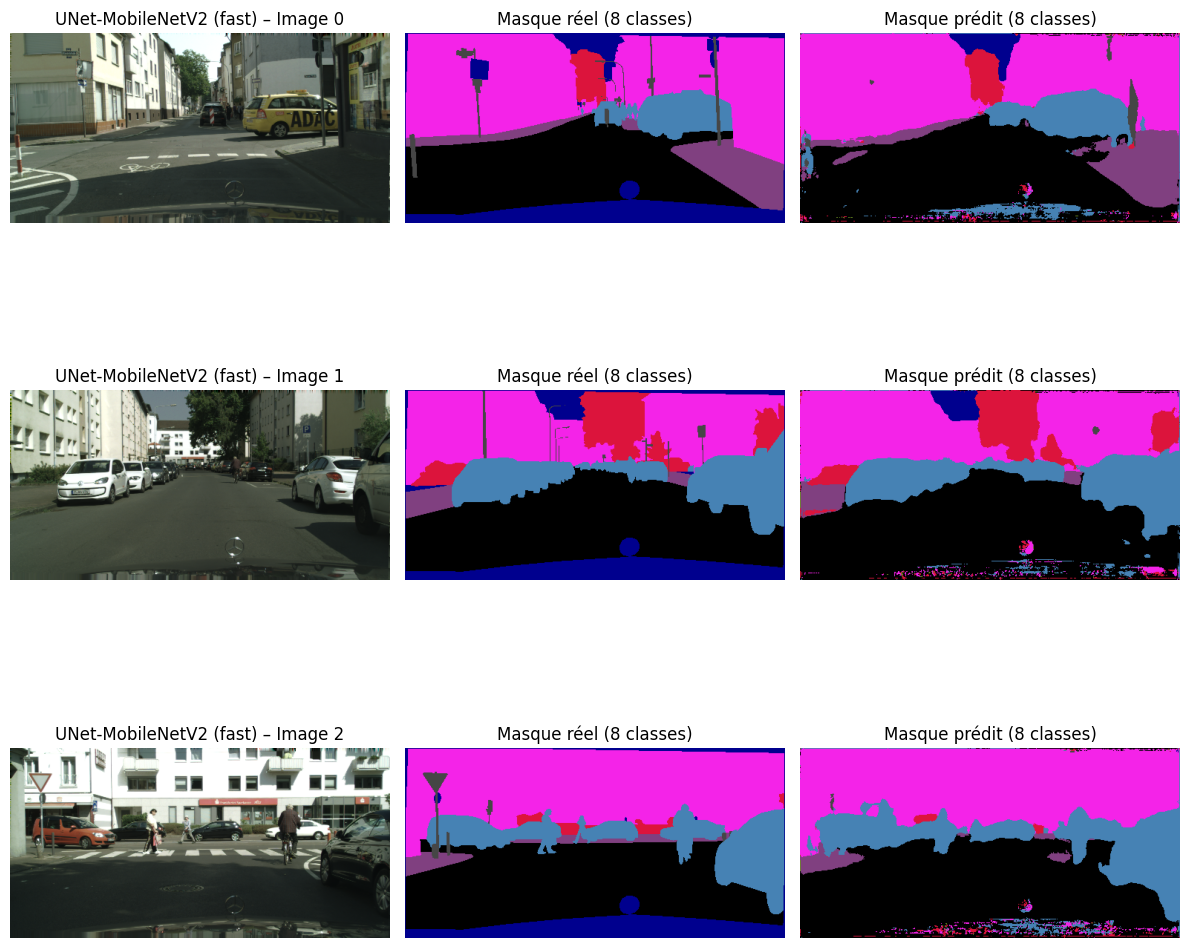

In [17]:
# %% 7.4 – Visualisation qualitative des prédictions sur le split val

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import tensorflow as tf

# Si la fonction de coloration n'est pas encore définie dans le noyau, on la définit ici
try:
    mask_8c_to_color
except NameError:
    def mask_8c_to_color(mask_8c: np.ndarray) -> np.ndarray:
        """
        Convertit un masque 8 classes (0..7) en image couleur RGB pour visualisation.
        Palette simple (inspirée de Cityscapes, mais uniquement pour l'affichage).
        """
        palette = np.array([
            [  0,   0,   0],   # 0 : fond / unlabeled
            [128,  64, 128],   # 1 : route
            [244,  35, 232],   # 2 : trottoir
            [ 70,  70,  70],   # 3 : bâtiment
            [107, 142,  35],   # 4 : végétation
            [ 70, 130, 180],   # 5 : ciel
            [220,  20,  60],   # 6 : piéton
            [  0,   0, 142],   # 7 : voiture
        ], dtype=np.uint8)

        mask_8c = np.asarray(mask_8c, dtype=np.int32)

        # On clippe pour éviter les valeurs hors plage
        mask_clipped = np.clip(mask_8c, 0, len(palette) - 1)
        return palette[mask_clipped]

def show_predictions_on_val(model, model_name: str, n_examples: int = 3):
    """
    Affiche quelques prédictions du modèle sur un batch du split val :
    - image d'entrée
    - masque réel (couleur)
    - masque prédit (couleur)
    """
    # On prend un petit batch de val
    for imgs, masks_true in val_ds.take(1):
        preds = model.predict(imgs)
        preds_classes = tf.argmax(preds, axis=-1).numpy().astype(np.uint8)
        imgs_np = imgs.numpy()
        masks_true_np = masks_true.numpy().astype(np.uint8)
        break

    n_examples = min(n_examples, imgs_np.shape[0])

    plt.figure(figsize=(12, 4 * n_examples))
    for i in range(n_examples):
        img = imgs_np[i]
        mask_true = masks_true_np[i]
        mask_pred = preds_classes[i]

        # Conversion en couleur
        mask_true_color = mask_8c_to_color(mask_true)
        mask_pred_color = mask_8c_to_color(mask_pred)

        row = i * 3

        plt.subplot(n_examples, 3, row + 1)
        plt.imshow(img)
        plt.title(f"{model_name} – Image {i}")
        plt.axis("off")

        plt.subplot(n_examples, 3, row + 2)
        plt.imshow(mask_true_color)
        plt.title("Masque réel (8 classes)")
        plt.axis("off")

        plt.subplot(n_examples, 3, row + 3)
        plt.imshow(mask_pred_color)
        plt.title("Masque prédit (8 classes)")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Exemple d'appel : visualiser les prédictions du modèle retenu
best_model_path = Path("models/unet_mobilenetv2_8c_fast.keras")
best_model = tf.keras.models.load_model(
    best_model_path,
    custom_objects={"dice_soft_macro": dice_soft_macro},
)
show_predictions_on_val(best_model, model_name="UNet-MobileNetV2 (fast)", n_examples=3)
